In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv(r'C:\Users\ADMIN\Downloads\prokabbadi.csv')

In [3]:
df

,Team,Matches_played,Matches_won,Matches_lost,Total_pts,Avg_pts,Successful_raids,Successful_tackles,Raid_pts,Tackle_pts,Avg_raid_pts,Avg_tackle_pts,Super_tackles,DOD_raid_pts,Total_pts_conceded,Super_raids,Total_raids,All_outs_inflicted,All_outs_conceded
0,Patna Pirates,22,10,11,844,38.36,413,187,516,201,23.25,9.14,22,65,812,11,912,35,24
1,Telugu Titans,21,12,9,789,37.57,356,209,458,227,21.81,10.81,18,63,744,8,864,28,28
2,Puneri Paltan,21,14,7,792,37.71,351,220,420,244,20.00,11.62,27,52,728,11,844,39,20
3,Haryana Steelers,19,10,9,724,38.11,321,195,407,223,21.42,11.74,28,43,709,8,790,31,30
4,Bengaluru Bulls,20,11,8,721,36.05,318,203,401,221,20.05,11.05,19,56,662,7,815,28,21
5,Bengal Warriorz,18,6,12,698,38.78,369,146,462,160,25.67,8.89,16,24,807,8,751,20,34
6,Dabang Delhi KC,20,15,5,705,35.25,299,199,395,207,19.75,10.35,10,65,681,20,796,30,20
7,Jaipur Pink Panthers,20,9,11,665,33.25,310,171,385,188,19.25,9.40,19,45,735,9,830,21,28
8,U Mumba,19,10,9,663,34.89,288,194,352,219,18.53,11.53,27,47,687,11,807,20,25
9,Tamil Thalaivas,18,6,12,621,34.50,285,182,354,195,19.67,10.83,14,42,656,8,738,21,27


In [4]:
print("\n Dataset Shape:", df.shape)
print("\n Columns:\n", df.columns)
print("\n Summary Stats:\n", df.describe())
print("\n Missing Values:\n", df.isnull().sum())


 Dataset Shape: (12, 19)

 Columns:
 Index(['Team', 'Matches_played', 'Matches_won', 'Matches_lost', 'Total_pts',
       'Avg_pts', 'Successful_raids', 'Successful_tackles', 'Raid_pts',
       'Tackle_pts', 'Avg_raid_pts', 'Avg_tackle_pts', 'Super_tackles',
       'DOD_raid_pts', 'Total_pts_conceded', 'Super_raids', 'Total_raids',
       'All_outs_inflicted', 'All_outs_conceded'],
      dtype='object')

 Summary Stats:
        Matches_played  Matches_won  Matches_lost   Total_pts    Avg_pts  \
count       12.000000    12.000000     12.000000   12.000000  12.000000   
mean        19.500000     9.666667      9.666667  699.583333  35.803333   
std          1.381699     3.055050      2.229282   81.433139   2.299412   
min         18.000000     6.000000      5.000000  577.000000  32.060000   
25%         18.000000     6.750000      8.750000  652.500000  34.187500   
50%         19.500000    10.000000     10.000000  701.500000  35.650000   
75%         20.250000    11.250000     11.250000  

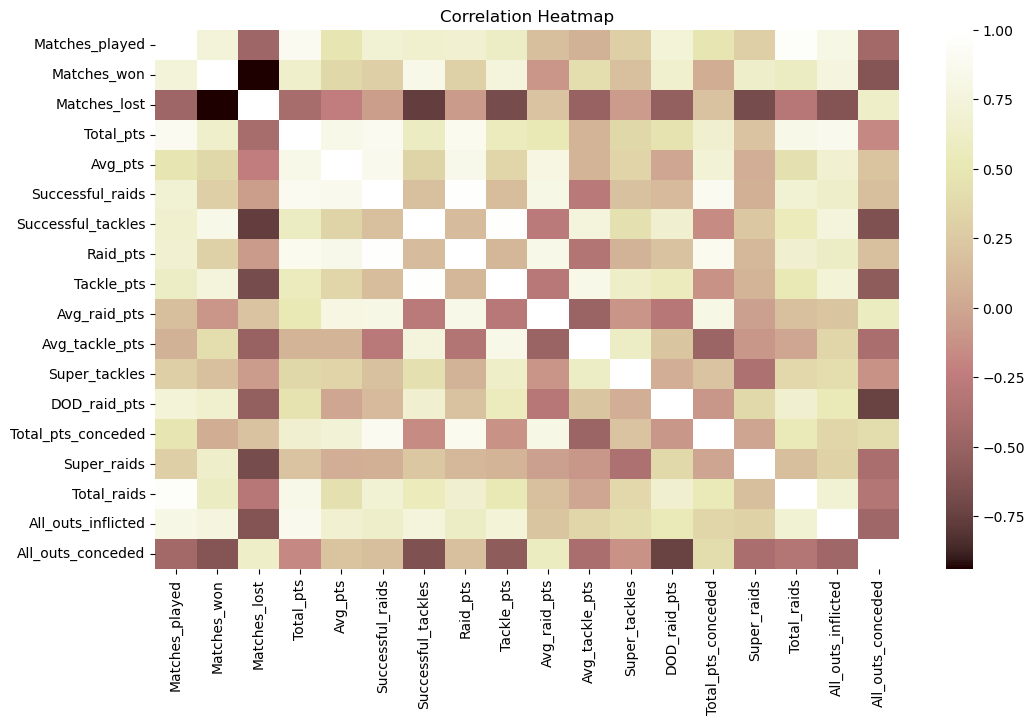

In [37]:
# Correlation Matrix

# Now create the heatmap with only numerical data
plt.figure(figsize=(12,7))
sns.heatmap(numeric_df.corr(), annot=False, cmap='pink')
plt.title("Correlation Heatmap")
plt.show()


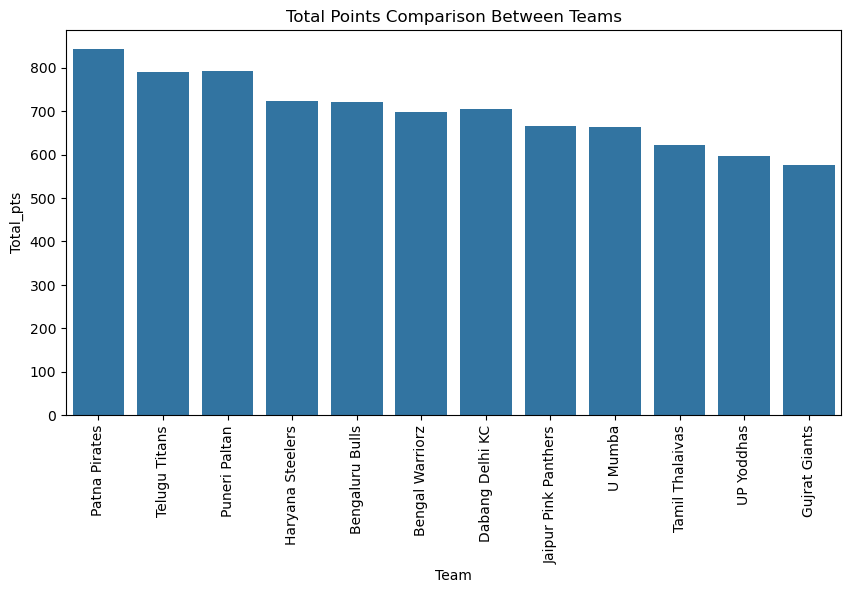

In [9]:
# Visualization
plt.figure(figsize=(10,5))
sns.barplot(x="Team", y="Total_pts", data=df)
plt.xticks(rotation=90)
plt.title("Total Points Comparison Between Teams")
plt.show()


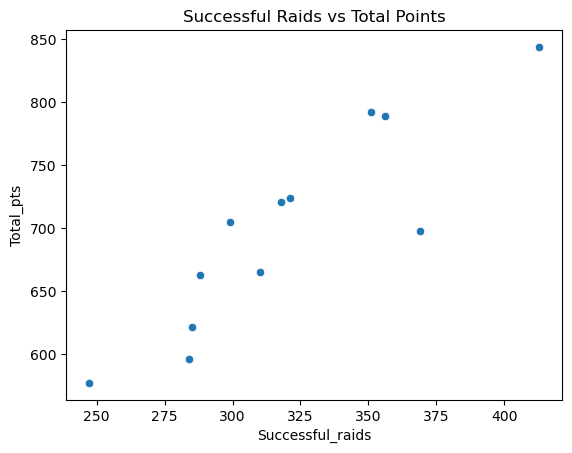

In [12]:
sns.scatterplot(x="Successful_raids", y="Total_pts", data=df)
plt.title("Successful Raids vs Total Points")
plt.show()


In [35]:
# Linear Regression (Predict Total Points)

# Independent variables (X) except Team column
X = df.drop(["Total_pts", "Team"], axis=1)
y = df["Total_pts"]

In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
# Linear Regression (Predict Total Points)
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [33]:
# Predictions
y_pred = model.predict(X_test)

In [22]:
print(" R2 Score:", r2_score(y_test, y_pred))
print(" RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

 R2 Score: 0.9949681281043086
 RMSE: 7.908189331377792


In [23]:
# Coefficients

coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\n🔹 Feature Importance:\n", coef_df.sort_values(by="Coefficient", ascending=False))



🔹 Feature Importance:
                Feature  Coefficient
15  All_outs_inflicted     1.040648
6             Raid_pts     0.646681
5   Successful_tackles     0.609196
7           Tackle_pts     0.590794
13         Super_raids     0.534704
4     Successful_raids     0.436530
1          Matches_won     0.325699
14         Total_raids     0.152243
0       Matches_played     0.065114
3              Avg_pts     0.047960
12  Total_pts_conceded     0.006492
9       Avg_tackle_pts     0.000146
10       Super_tackles    -0.019197
16   All_outs_conceded    -0.020648
8         Avg_raid_pts    -0.026056
11        DOD_raid_pts    -0.175060
2         Matches_lost    -0.242959


In [24]:
print("\nSample Prediction:", model.predict([X.iloc[0]]))


Sample Prediction: [837.84817372]


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
